In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import pmdarima as pm
from sklearn.metrics import mean_absolute_error

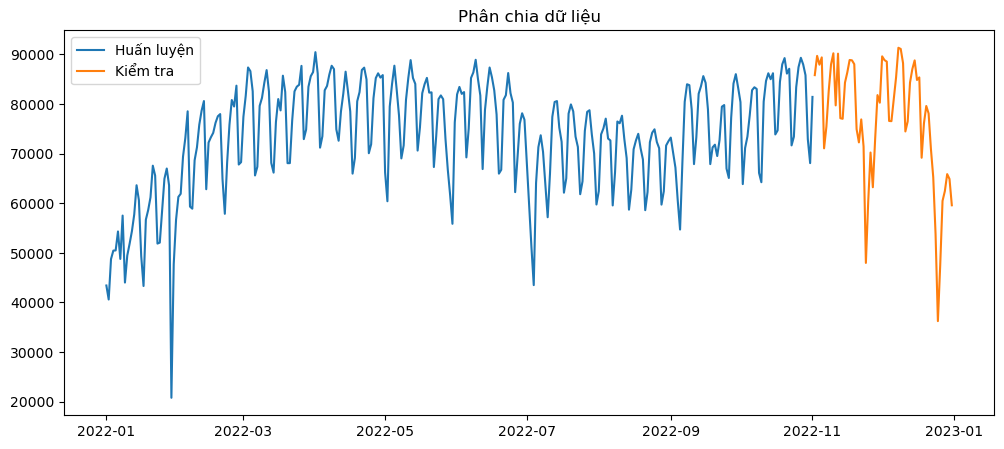

In [2]:
file_path = '..\processed\kpi_daily_2022.csv'
df_daily = pd.read_csv(
    file_path,
    parse_dates=['tpep_pickup_datetime'],
    index_col='tpep_pickup_datetime'
)

df_cp_daily = df_daily.copy()
val_last_week_1 = df_cp_daily.loc['2022-09-11', 'total_trips']
val_last_week_2 = df_cp_daily.loc['2022-09-10', 'total_trips']
df_cp_daily.loc['2022-09-18', 'total_trips'] = val_last_week_1 # Sửa lại giá trị cho ngày 18/09/2022 bằng giá trị của ngày 11/09/2022
df_cp_daily.loc['2022-09-17', 'total_trips'] = val_last_week_2 # Sửa lại giá trị cho ngày 17/09/2022 bằng giá trị của ngày 10/09/2022

test_days = 60
train = df_cp_daily.iloc[:-test_days]
test = df_cp_daily.iloc[-test_days:]

plt.figure(figsize=(12,5))
plt.plot(train['total_trips'], label='Huấn luyện')
plt.plot(test['total_trips'], label='Kiểm tra')
plt.title('Phân chia dữ liệu')
plt.legend()
plt.show()

In [3]:
# Thiếu lập Auto ARIMA model tìm AIC thấp nhất
model = pm.auto_arima(
    train['total_trips'],
    start_p = 1, start_q = 1,
    max_p = 3, max_q = 3,
    m = 7, # Chu kỳ theo tuần
    start_P = 0, seasonal = True,
    d = None, D = 1,
    trace = True,
    error_action = 'ignore', # Bỏ qua các mô hình không hội tụ
    suppress_warnings = True,
    stepwise = True # Sử dụng phương pháp leo đồi (thay cho vét cạn để tăng tốc độ)
)

print("\n" + "="*40)
print("WINNER! MÔ HÌNH TỐT NHẤT LÀ:")
print("="*40)
print(model.summary())

Performing stepwise search to minimize aic
 ARIMA(1,0,1)(0,1,1)[7] intercept   : AIC=5966.426, Time=0.92 sec
 ARIMA(0,0,0)(0,1,0)[7] intercept   : AIC=6152.453, Time=0.03 sec
 ARIMA(1,0,0)(1,1,0)[7] intercept   : AIC=6005.509, Time=0.20 sec
 ARIMA(0,0,1)(0,1,1)[7] intercept   : AIC=6057.057, Time=0.16 sec
 ARIMA(0,0,0)(0,1,0)[7]             : AIC=6154.013, Time=0.03 sec
 ARIMA(1,0,1)(0,1,0)[7] intercept   : AIC=6063.838, Time=0.12 sec
 ARIMA(1,0,1)(1,1,1)[7] intercept   : AIC=5984.592, Time=0.33 sec
 ARIMA(1,0,1)(0,1,2)[7] intercept   : AIC=5966.347, Time=2.65 sec
 ARIMA(1,0,1)(1,1,2)[7] intercept   : AIC=inf, Time=3.28 sec
 ARIMA(0,0,1)(0,1,2)[7] intercept   : AIC=6058.912, Time=0.44 sec
 ARIMA(1,0,0)(0,1,2)[7] intercept   : AIC=5991.677, Time=0.49 sec
 ARIMA(2,0,1)(0,1,2)[7] intercept   : AIC=5987.118, Time=0.95 sec
 ARIMA(1,0,2)(0,1,2)[7] intercept   : AIC=5984.643, Time=0.78 sec
 ARIMA(0,0,0)(0,1,2)[7] intercept   : AIC=6142.901, Time=0.31 sec
 ARIMA(0,0,2)(0,1,2)[7] intercept   : 

MAE của mô hình SARIMA: 8198.28
MAPE của mô hình SARIMA: 10.65%


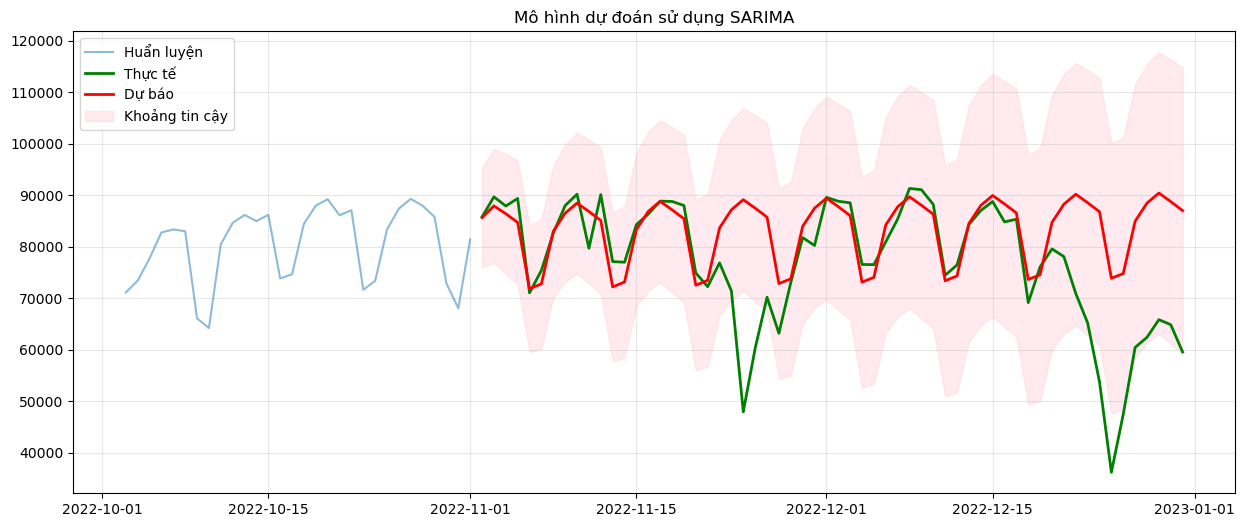

In [4]:
# Mô hình dự báo trên tập kiểm tra

# Dự đoán đưa ra khoảng tin cậy
prediction , conf_int = model.predict(n_periods=test_days, return_conf_int=True)

prediction_series = pd.Series(prediction, index=test.index)

# Tính toán sai số MAE và MAPE
mae_sarima = mean_absolute_error(test['total_trips'], prediction)
mean__trips = test['total_trips'].mean()
mape_sarima = mae_sarima / mean__trips * 100

print(f'MAE của mô hình SARIMA: {mae_sarima:.2f}')
print(f'MAPE của mô hình SARIMA: {mape_sarima:.2f}%')

# Vẽ biểu đồ kết quả dự báo
plt.figure(figsize=(15,6))
plt.plot(train.index[-30:], train['total_trips'][-30:], label='Huẩn luyện', alpha = 0.5) # Dữ liệu huấn luyện (30 ngày cuối)
plt.plot(test.index, test['total_trips'], label='Thực tế', color='green', linewidth = 2) # Dữ liệu thực tế
plt.plot(prediction_series.index, prediction_series, label='Dự báo', color='red', linewidth = 2) # Dự báo

# Vẽ khoảng tin cậy
plt.fill_between(test.index,
                 conf_int[:, 0],
                 conf_int[:, 1],
                 color='pink', alpha=0.3, label='Khoảng tin cậy')

plt.title('Mô hình dự đoán sử dụng SARIMA')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()

In [ ]:
# Dữ liệu dự đoán có sai số cao do dữ liệu những ngày đầu tập test bị coi là chưa xảy ra (chưa có dữ liệu cho việc dự đoán những ngày sau)
# Không có dữ liệu -> dự đoán càng xa càng sai lệch

C:\Users\ADMIN\AppData\Local\Temp\ipykernel_9140\2181880712.py:9: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  pred = model.predict(n_periods=1)[0]  # Chỉ dự đoán 1 ngày tiếp theo


MAE của mô hình SARIMA cuốn chiếu: 4075.81
MAPE của mô hình SARIMA cuốn chiếu: 5.29%


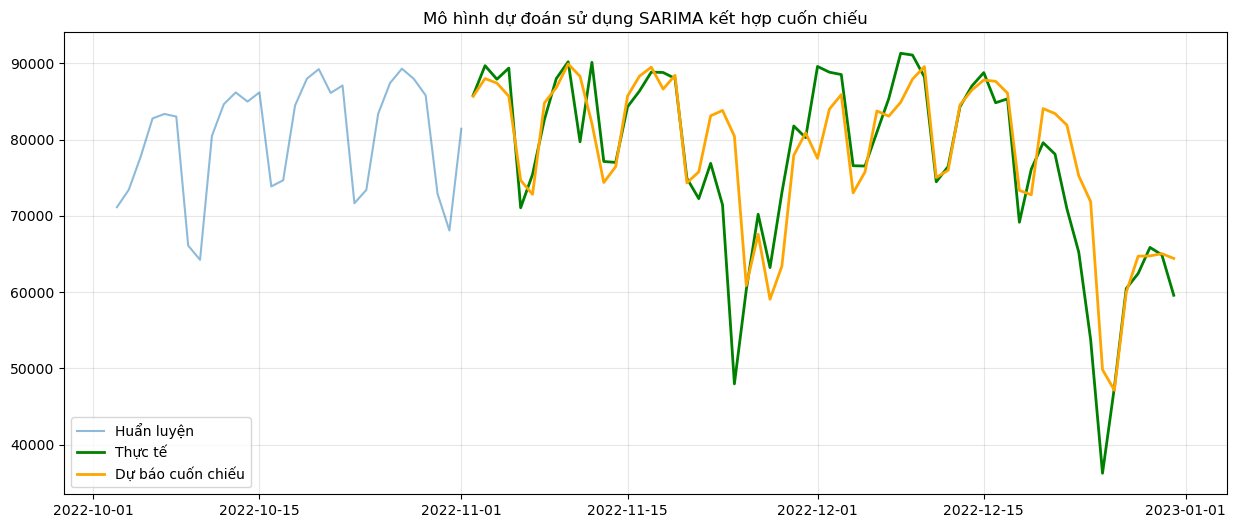

In [5]:
# Sử dụng cuốn chiếu để lưu dữ liệu những ngày đã dự đoán

# Tạo danh sách rỗng để lưu trữ các dự đoán cuốn chiếu
rolling_predictions = []
test_obs = test['total_trips'].values

# Bắt đầu dự đoán cuốn chiếu
for x in test_obs:
    pred = model.predict(n_periods=1)[0]  # Chỉ dự đoán 1 ngày tiếp theo

    rolling_predictions.append(pred) # Lưu dự đoán vào danh sách

    model.update(x)  # Cập nhật mô hình với quan sát thực tế mới

# Tổng hợp kết quả
rolling_pred_series = pd.Series(rolling_predictions, index=test.index)

# Tính toán sai số MAE và MAPE cho dự đoán cuốn chiếu
mae_rolling = mean_absolute_error(test['total_trips'], rolling_pred_series)
mean__trips = test['total_trips'].mean()
mape_rolling = mae_rolling / mean__trips * 100

print(f'MAE của mô hình SARIMA cuốn chiếu: {mae_rolling:.2f}')
print(f'MAPE của mô hình SARIMA cuốn chiếu: {mape_rolling:.2f}%')

# Vẽ biểu đồ kết quả dự báo cuốn chiếu
plt.figure(figsize=(15,6))
plt.plot(train.index[-30:], train['total_trips'][-30:], label='Huẩn luyện', alpha = 0.5) # Dữ liệu huấn luyện (30 ngày cuối)
plt.plot(test.index, test['total_trips'], label='Thực tế', color='green', linewidth = 2) # Dữ liệu thực tế
plt.plot(rolling_pred_series.index, rolling_pred_series, label='Dự báo cuốn chiếu', color='orange', linewidth = 2) # Dự báo cuốn chiếu
plt.title('Mô hình dự đoán sử dụng SARIMA kết hợp cuốn chiếu')
plt.legend()
plt.grid(True, alpha = 0.3)
plt.show()
